<a href="https://colab.research.google.com/github/AishahAbdulHakeem/skincare-ai/blob/main/03_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 Model Training & Evaluation

This notebook:
- Builds ingredient and sentiment feature matrices
- Trains three models of increasing complexity
- Evaluates performance using RMSE and R²
- Identifies the best model for predicting product ratings
- Saves the final model for use in the app

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
skincare = pd.read_pickle("/content/drive/MyDrive/skincare-ai/data/processed/skincare_final.pkl")

with open("/content/drive/MyDrive/skincare-ai/data/processed/top_ingredients.pkl", "rb") as f:
    top_ingredients = pickle.load(f)

print("Data shape:", skincare.shape)
print("Top ingredients:", len(top_ingredients))

Data shape: (2420, 7)
Top ingredients: 219


In [ ]:
skincare = skincare.dropna(subset=['rating']).reset_index(drop=True)

print("Products after dropping missing ratings:", len(skincare))

Products after dropping missing ratings: 2351


## Feature Engineering
Build two feature sets:
- Ingredient matrix: 224 binary columns (1 if ingredient present, 0 if not)
- Sentiment matrix: mean sentiment, % positive reviews, review count

In [ ]:
top_ingredients_list = sorted(list(top_ingredients))

def encode_ingredients(ingredient_list):
    return [1 if ing in ingredient_list else 0 for ing in top_ingredients_list]

X_ingredients = np.array(skincare['ingredient_list'].apply(encode_ingredients).tolist())

print("Ingredient feature matrix shape:", X_ingredients.shape)

Ingredient feature matrix shape: (2351, 219)


In [ ]:
X_sentiment = skincare[['mean_sentiment', 'pct_positive', 'review_count']].values

scaler = StandardScaler()
X_sentiment_scaled = scaler.fit_transform(X_sentiment)

print("Sentiment feature matrix shape:", X_sentiment_scaled.shape)

Sentiment feature matrix shape: (2351, 3)


## Model 1 — Baseline
Ridge regression using ingredient features only.
This establishes the baseline performance to beat.

In [ ]:
y = skincare['rating'].values

X_ing_train, X_ing_test, y_train, y_test = train_test_split(
    X_ingredients, y, test_size=0.2, random_state=42
)

ridge_baseline = Ridge(alpha=1.0)
ridge_baseline.fit(X_ing_train, y_train)
y_pred_baseline = ridge_baseline.predict(X_ing_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline   = r2_score(y_test, y_pred_baseline)

print(f"RMSE: {rmse_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}")

=== Model 1: Ridge (Ingredients Only) ===
RMSE: 0.4854
R²:   -0.0118


## Model 2 — Ingredients + Sentiment
Adding sentiment features to the ingredient matrix.

In [ ]:
X_full = np.hstack([X_ingredients, X_sentiment_scaled])

X_full_train, X_full_test, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

ridge_full = Ridge(alpha=1.0)
ridge_full.fit(X_full_train, y_train)
y_pred_ridge_full = ridge_full.predict(X_full_test)

rmse_ridge_full = np.sqrt(mean_squared_error(y_test, y_pred_ridge_full))
r2_ridge_full   = r2_score(y_test, y_pred_ridge_full)

print(f"RMSE: {rmse_ridge_full:.4f}")
print(f"R²:   {r2_ridge_full:.4f}")

=== Model 2: Ridge (Ingredients + Sentiment) ===
RMSE: 0.3486
R²:   0.4782


## Model 3 — Gradient Boosting
Gradient Boosting on the full feature set (ingredients + sentiment).
Tree-based models can capture ingredient combinations that linear models miss.

In [ ]:
gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                      learning_rate=0.05, random_state=42)
gb_model.fit(X_full_train, y_train)
y_pred_gb = gb_model.predict(X_full_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print("=== Model 3: GB (Ingredients + Sentiment) ===")
print(f"RMSE: {rmse_gb:.4f}")
print(f"R²:   {r2_gb:.4f}")

=== Model 3: GB (Ingredients + Sentiment) ===
RMSE: 0.3352
R²:   0.5176


## Results
Compare all three models. Gradient Boosting with ingredients and sentiment
features achieves the best performance (R² ≈ 0.51).

In [ ]:
all_results = pd.DataFrame({
    'Model': [
        'Ridge — Ingredients Only (Baseline)',
        'Ridge — Ingredients + Sentiment',
        'GB — Ingredients + Sentiment (Final)',
    ],
    'RMSE': [rmse_baseline, rmse_ridge_full, rmse_gb],
    'R²':   [r2_baseline,   r2_ridge_full,   r2_gb]
})

all_results = all_results.sort_values('R²', ascending=False).reset_index(drop=True)
print(all_results.to_string(index=False))

                               Model     RMSE        R²
GB — Ingredients + Sentiment (Final) 0.335175  0.517563
     Ridge — Ingredients + Sentiment 0.348567  0.478241
 Ridge — Ingredients Only (Baseline) 0.485397 -0.011792


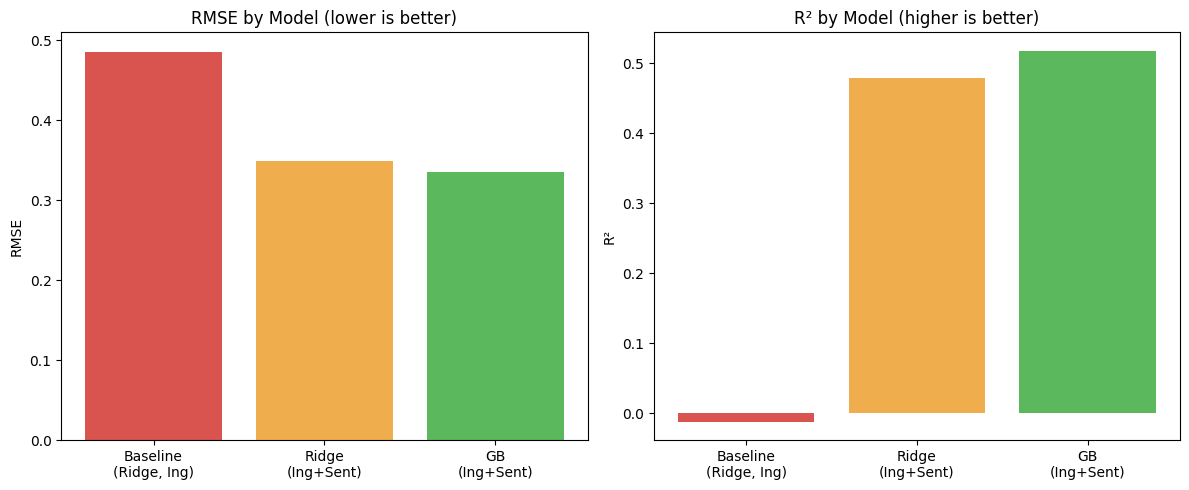

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models    = ['Baseline\n(Ridge, Ing)', 'Ridge\n(Ing+Sent)', 'GB\n(Ing+Sent)']
rmse_vals = [rmse_baseline, rmse_ridge_full, rmse_gb]
r2_vals   = [r2_baseline,   r2_ridge_full,   r2_gb]
colors    = ['#d9534f', '#f0ad4e', '#5cb85c']

axes[0].bar(models, rmse_vals, color=colors)
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].set_ylabel('RMSE')

axes[1].bar(models, r2_vals, color=colors)
axes[1].set_title('R² by Model (higher is better)')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

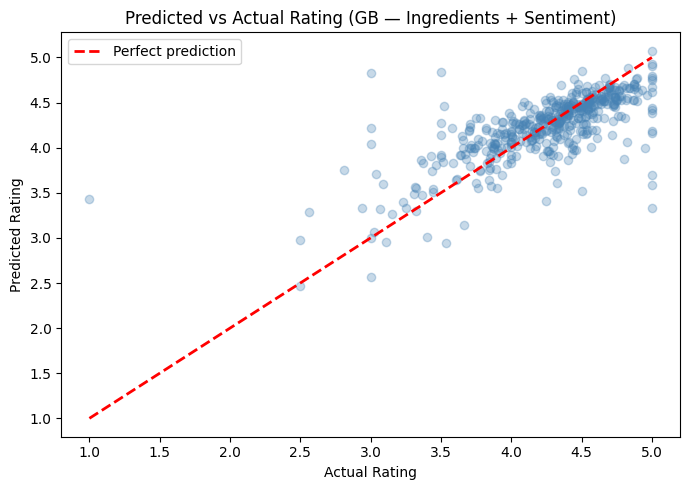

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_gb, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Predicted vs Actual Rating (GB — Ingredients + Sentiment)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs("/content/drive/MyDrive/skincare-ai/models", exist_ok=True)

with open("/content/drive/MyDrive/skincare-ai/models/best_model_final.pkl", "wb") as f:
    pickle.dump(gb_model, f)

with open("/content/drive/MyDrive/skincare-ai/models/scaler_final.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("/content/drive/MyDrive/skincare-ai/models/top_ingredients_list.pkl", "wb") as f:
    pickle.dump(top_ingredients_list, f)

print("Saved: best_model_final.pkl, scaler_final.pkl, top_ingredients_list.pkl")

Saved: best_model_final.pkl, scaler_final.pkl, top_ingredients_list.pkl
